In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

# 데이터 정의
data = """model,experiment,overall_mae,incident_mae
STAEformer,BASELINE,11.6513,13.3810
STAEformer,ONLY_GATE,11.4339,13.3643
STAEformer,ONLY_REPLAY_001,11.5670,13.0322
STAEformer,ONLY_REPLAY_0001,11.6477,13.7263
STAEformer,REPLAY_FULL_UPDATE_001,11.6031,14.2291
STAEformer,REPLAY_FULL_UPDATE_0001,11.5805,12.8286
STAEformer,REPLAY_GATE_UPDATE_001,11.6976,14.1557
STAEformer,REPLAY_GATE_UPDATE_0001,11.4892,13.9537
STGCN,BASELINE,18.7285,22.4305
STGCN,ONLY_GATE,16.8994,30.9697
STGCN,ONLY_REPLAY_001,15.9275,17.4752
STGCN,ONLY_REPLAY_0001,18.8140,22.5939
STGCN,REPLAY_FULL_UPDATE_001,16.7657,29.9027
STGCN,REPLAY_FULL_UPDATE_0001,17.1646,29.6713
STGCN,REPLAY_GATE_UPDATE_001,20.3228,33.4477
STGCN,REPLAY_GATE_UPDATE_0001,18.9248,33.7021
STGformer,BASELINE,11.4468,15.9543
STGformer,ONLY_GATE,11.4249,16.0314
STGformer,ONLY_REPLAY_001,11.3917,16.2764
STGformer,ONLY_REPLAY_0001,11.4333,16.1026
STGformer,REPLAY_GATE_UPDATE_001,11.3922,15.7253
STGformer,REPLAY_GATE_UPDATE_0001,11.4637,16.3743
AGCRN,BASELINE,13.7813,36.7000
AGCRN,ONLY_GATE,14.3713,16.0128
AGCRN,ONLY_REPLAY_001,13.7788,37.8961
AGCRN,ONLY_REPLAY_0001,13.8227,36.7176
AGCRN,REPLAY_FULL_UPDATE_001,15.6201,16.7529
AGCRN,REPLAY_FULL_UPDATE_0001,19.4995,25.1383
AGCRN,REPLAY_GATE_UPDATE_001,15.4745,32.6290
AGCRN,REPLAY_GATE_UPDATE_0001,14.9919,29.2870"""

# DataFrame으로 변환
df = pd.read_csv(StringIO(data))

# 필요한 실험만 필터링 (ONLY_REPLAY_0001 제외)
target_experiments = ['BASELINE', 'ONLY_GATE', 'ONLY_REPLAY_001', 'REPLAY_FULL_UPDATE_0001']
df_filtered = df[df['experiment'].isin(target_experiments)].copy()

# 실험 순서 지정
experiment_order = ['BASELINE', 'ONLY_GATE', 'ONLY_REPLAY_001', 'REPLAY_FULL_UPDATE_0001']
df_filtered['experiment'] = pd.Categorical(df_filtered['experiment'], categories=experiment_order, ordered=True)
df_filtered = df_filtered.sort_values(['model', 'experiment'])

print("필터링된 데이터:")
print(df_filtered)

필터링된 데이터:
         model               experiment  overall_mae  incident_mae
22       AGCRN                 BASELINE      13.7813       36.7000
23       AGCRN                ONLY_GATE      14.3713       16.0128
24       AGCRN          ONLY_REPLAY_001      13.7788       37.8961
27       AGCRN  REPLAY_FULL_UPDATE_0001      19.4995       25.1383
0   STAEformer                 BASELINE      11.6513       13.3810
1   STAEformer                ONLY_GATE      11.4339       13.3643
2   STAEformer          ONLY_REPLAY_001      11.5670       13.0322
5   STAEformer  REPLAY_FULL_UPDATE_0001      11.5805       12.8286
8        STGCN                 BASELINE      18.7285       22.4305
9        STGCN                ONLY_GATE      16.8994       30.9697
10       STGCN          ONLY_REPLAY_001      15.9275       17.4752
13       STGCN  REPLAY_FULL_UPDATE_0001      17.1646       29.6713
16   STGformer                 BASELINE      11.4468       15.9543
17   STGformer                ONLY_GATE      11.4249

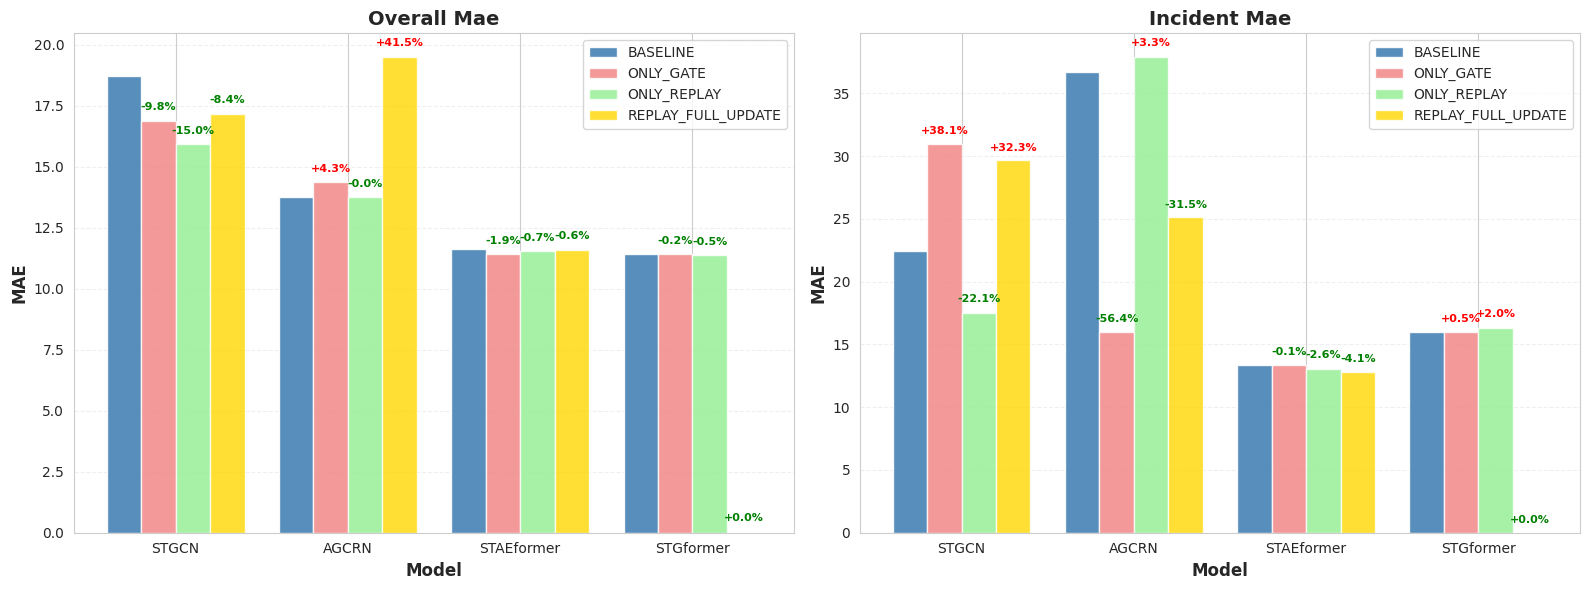

In [21]:
# 시각화 설정
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['font.size'] = 10
sns.set_style("whitegrid")

# 모델별로 그룹화하여 시각화
# 모델 순서 지정: STGCN, AGCRN, STAEformer, STGformer
model_order = ['STGCN-Cheb', 'STGCN', 'AGCRN', 'STAEformer', 'STGformer']
available_models = df_filtered['model'].unique()
# 순서대로 정렬 (데이터에 있는 모델만 포함)
models = [m for m in model_order if m in available_models]
n_models = len(models)
n_experiments = len(experiment_order)

# Overall MAE와 Incident MAE에 대해 각각 차트 생성
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for metric_idx, metric in enumerate(['overall_mae', 'incident_mae']):
    ax = axes[metric_idx]
    
    # 각 모델별로 데이터 준비
    x = np.arange(n_models)
    width = 0.2  # 각 실험별 bar 너비
    
    # 각 실험별로 bar 그리기
    for exp_idx, exp_name in enumerate(experiment_order):
        values = []
        deltas = []
        baseline_values = []
        
        for model in models:
            model_data = df_filtered[(df_filtered['model'] == model) & (df_filtered['experiment'] == exp_name)]
            baseline_data = df_filtered[(df_filtered['model'] == model) & (df_filtered['experiment'] == 'BASELINE')]
            
            if not model_data.empty and not baseline_data.empty:
                value = model_data[metric].values[0]
                baseline_value = baseline_data[metric].values[0]
                # Delta를 percentage로 계산: ((value - baseline) / baseline) * 100
                delta_percent = ((value - baseline_value) / baseline_value) * 100
                
                values.append(value)
                deltas.append(delta_percent)
                baseline_values.append(baseline_value)
            else:
                values.append(0)
                deltas.append(0)
                baseline_values.append(0)
        
        # Bar 위치 계산
        bar_positions = x + (exp_idx - 1.5) * width
        
        # Bar 색상 설정
        if exp_name == 'BASELINE':
            color = 'steelblue'
            alpha = 0.9
        elif exp_name == 'ONLY_GATE':
            color = 'lightcoral'
            alpha = 0.8
        elif exp_name == 'ONLY_REPLAY_001':
            color = 'lightgreen'
            alpha = 0.8
        else:  # ONLY_REPLAY_0001
            color = 'gold'
            alpha = 0.8
        
        # 라벨 설정 (ONLY_REPLAY_001을 ONLY_REPLAY로 표시)
        display_label = exp_name.replace('_001', '').replace('_0001', '')
        # Bar 그리기
        bars = ax.bar(bar_positions, values, width, label=display_label, alpha=alpha, color=color)
        
        # Delta 표시 (BASELINE 제외)
        if exp_name != 'BASELINE':
            for i, (bar, delta) in enumerate(zip(bars, deltas)):
                height = bar.get_height()
                # Delta를 percentage로 bar 위에 표시
                ax.text(bar.get_x() + bar.get_width()/2., height + max(values) * 0.02,
                       f'{delta:+.1f}%',
                       ha='center', va='bottom', fontsize=8, fontweight='bold',
                       color='red' if delta > 0 else 'green')
    
    # 그래프 설정
    ax.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax.set_ylabel('MAE', fontsize=12, fontweight='bold')
    ax.set_title(f'{metric.replace("_", " ").title()}', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=0)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


/tmp/ipykernel_3605773/3223932700.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


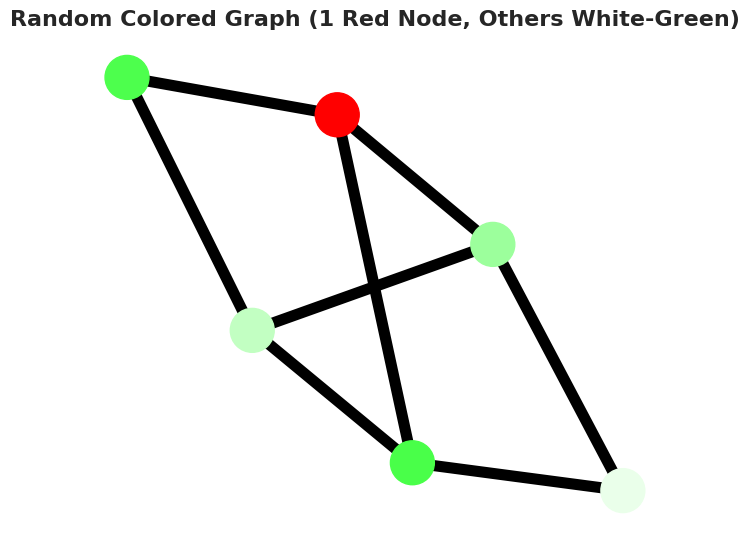

노드 색상 (RGB):
Node 0 (White-Green): RGB(0.9190550937053064, 1.0, 0.9190550937053064)
Node 1 (White-Green): RGB(0.6122628630696203, 1.0, 0.6122628630696203)
Node 2 (White-Green): RGB(0.28489376907523023, 1.0, 0.28489376907523023)
Node 3 (White-Green): RGB(0.759016184594165, 1.0, 0.759016184594165)
Node 4 (RED): RGB(1.0, 0.0, 0.0)
Node 5 (White-Green): RGB(0.30135414876933403, 1.0, 0.30135414876933403)


In [16]:
import networkx as nx
import random

# 그래프 생성 (6개 노드)
G = nx.Graph()

# 노드 추가
nodes = list(range(6))
G.add_nodes_from(nodes)

# Edge 추가 (적당히 연결)
edges = [(0, 1), (0, 2), (1, 3), (2, 4), (3, 5), (4, 5), (1, 4), (2, 3)]
G.add_edges_from(edges)

# 그래프 레이아웃 설정
pos = nx.spring_layout(G, seed=42)

# 노드 색상 랜덤 생성
node_colors = [None] * len(nodes)

# 1개 노드를 랜덤으로 선택해서 빨간색으로 설정
red_node_idx = random.randint(0, len(nodes) - 1)
node_colors[red_node_idx] = (1.0, 0.0, 0.0)  # 빨간색

# 나머지 노드들은 흰색-초록색 사이에서 랜덤하게
for i in range(len(nodes)):
    if i != red_node_idx:
        # 흰색(1.0, 1.0, 1.0)에서 초록색(0.0, 1.0, 0.0)으로
        # R과 B를 동시에 감소시키고 G는 유지
        intensity = random.uniform(0.2, 1.0)  # 흰색에서 초록색으로의 강도
        node_colors[i] = (intensity, 1.0, intensity)  # R과 B를 동일하게, G는 최대값 유지

# 그래프 그리기
plt.figure(figsize=(6, 5))
nx.draw(G, pos, 
        with_labels=False, 
        node_color=node_colors,
        node_size=1000,
        edge_color='black',
        width=8)

plt.title("Random Colored Graph (1 Red Node, Others White-Green)", fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print("노드 색상 (RGB):")
for i, color in enumerate(node_colors):
    node_type = "RED" if i == red_node_idx else "White-Green"
    print(f"Node {i} ({node_type}): RGB{color}")
